In [68]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rc
rc("lines", linewidth=4)
rc("font", size = 18)

In [69]:
_R = 8.314 #J/mol/K
_rho = 997 #g/L
_Msol = 18 #g/mol
_Tfus = 273.15 #K
_DfusH = 6010 #J.mol-1

Msalt = {"NaCl" : 58.44, "CaCl2" : 110.98}

def get_c(w, Msalt = 1, Msol = 1) : 
    return _rho/Msalt * w / (w + Msalt/Msol * (1-w))

wCaCl2, TCaCl2 = np.loadtxt("Binary-H2O-CaCl2.csv", delimiter = ',', skiprows=1).T
TCaCl2 += 272.8
wCaCl2 /= 100
wNaCl, TNaCl = np.loadtxt("Binary-H2O-NaCl.csv", delimiter = ',', skiprows=1).T
wNaCl /= 100


cNaCl = get_c(wNaCl, Msalt = Msalt["NaCl"], Msol = _Msol)
cCaCl2 = get_c(wCaCl2, Msalt = Msalt["CaCl2"], Msol = _Msol)


#Loi Colligative
def get_Tfus(c) : 
    return _Tfus - _R*_Tfus**2 * _Msol / _DfusH / _rho * c


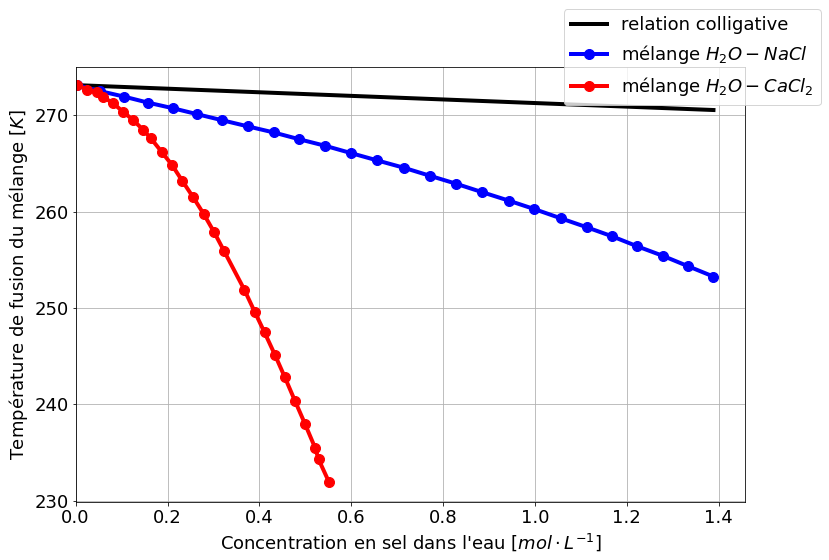

In [73]:
fig = plt.figure(figsize=(12,8))
ax = fig.subplots()
ax.plot(cNaCl, get_Tfus(cNaCl), color = 'black', label="relation colligative")
ax.plot(cNaCl, TNaCl, marker = 'o', color = 'blue', label="mélange $H_2O-NaCl$", markersize = 10)
ax.plot(cCaCl2, TCaCl2, marker = 'o', color = 'red', label="mélange $H_2O-CaCl_2$", markersize = 10)
ax.set_xlim(0,None)
ax.set_ylim(None,275)

ax.set_ylabel("Température de fusion du mélange [$K$]")
ax.set_xlabel("Concentration en sel dans l'eau [$mol \cdot L^{-1}$]")

ax.grid()
fig.legend()

fig.savefig("Corr01.pdf", dpi = 200)